In [2]:
import os, sys
os.chdir(r"E:\Uni\Final Project\Coding Artifact\medical-imputation")
sys.path.insert(0, os.getcwd())
print(os.getcwd())

E:\Uni\Final Project\Coding Artifact\medical-imputation


Searching for images in: E:\Uni\Final Project\Datasets\archive\chest_xray\test\NORMAL
Loaded 30 images.

--- Parameter Justification (Silhouette over subset) ---
k=2 | Avg silhouette=0.3278
k=3 | Avg silhouette=0.3517
k=4 | Avg silhouette=0.3597
k=5 | Avg silhouette=0.3446
k=6 | Avg silhouette=0.3299
Selected k=4

--- Running Chest X-Ray on 30 images ---
Missing rate: 10%
Missing rate: 20%
Missing rate: 30%

=== FINAL STATISTICS: Chest X-Ray ===
                       MAE                  RMSE                  PSNR                SSIM                 IoU                 Time          
                      mean        std       mean        std       mean       std      mean       std      mean       std       mean       std
Rate Method                                                                                                                                  
0.1  AR-DBSCAN   46.873857   6.256625  56.718923   7.990277  22.922278  1.301584  0.909203  0.006004  0.899667  0.041142   6

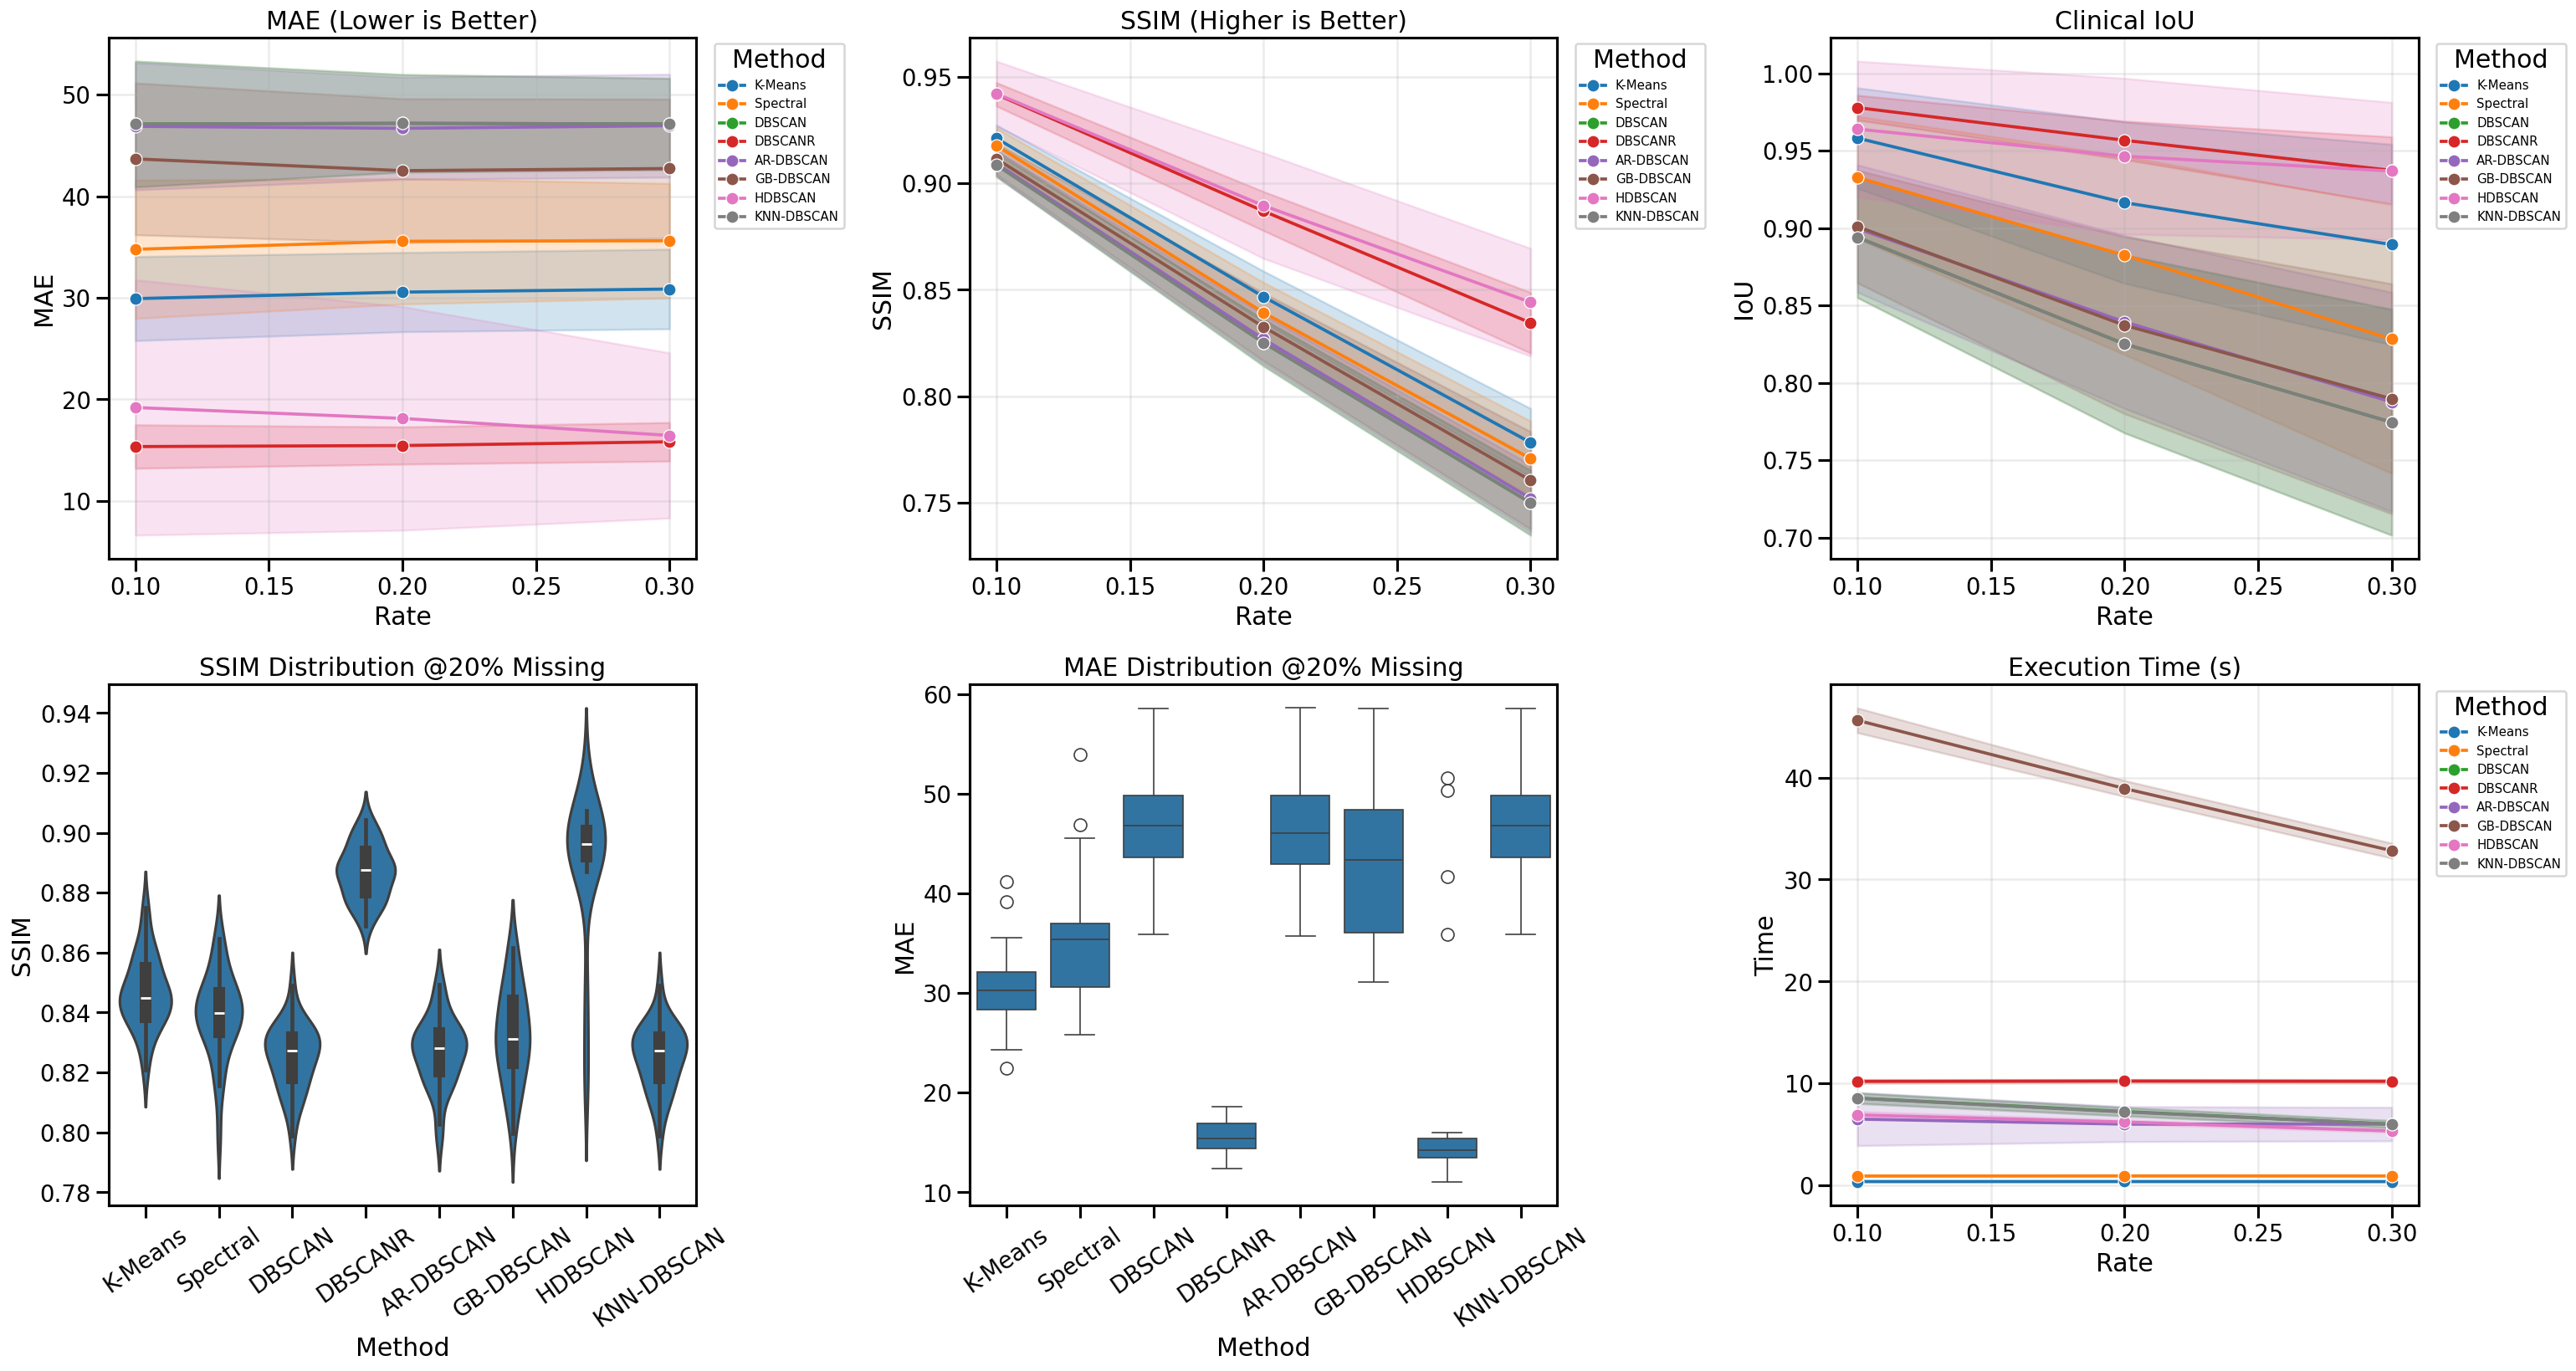

Saved figure: outputs\figures\Chest_X-Ray_metrics.png


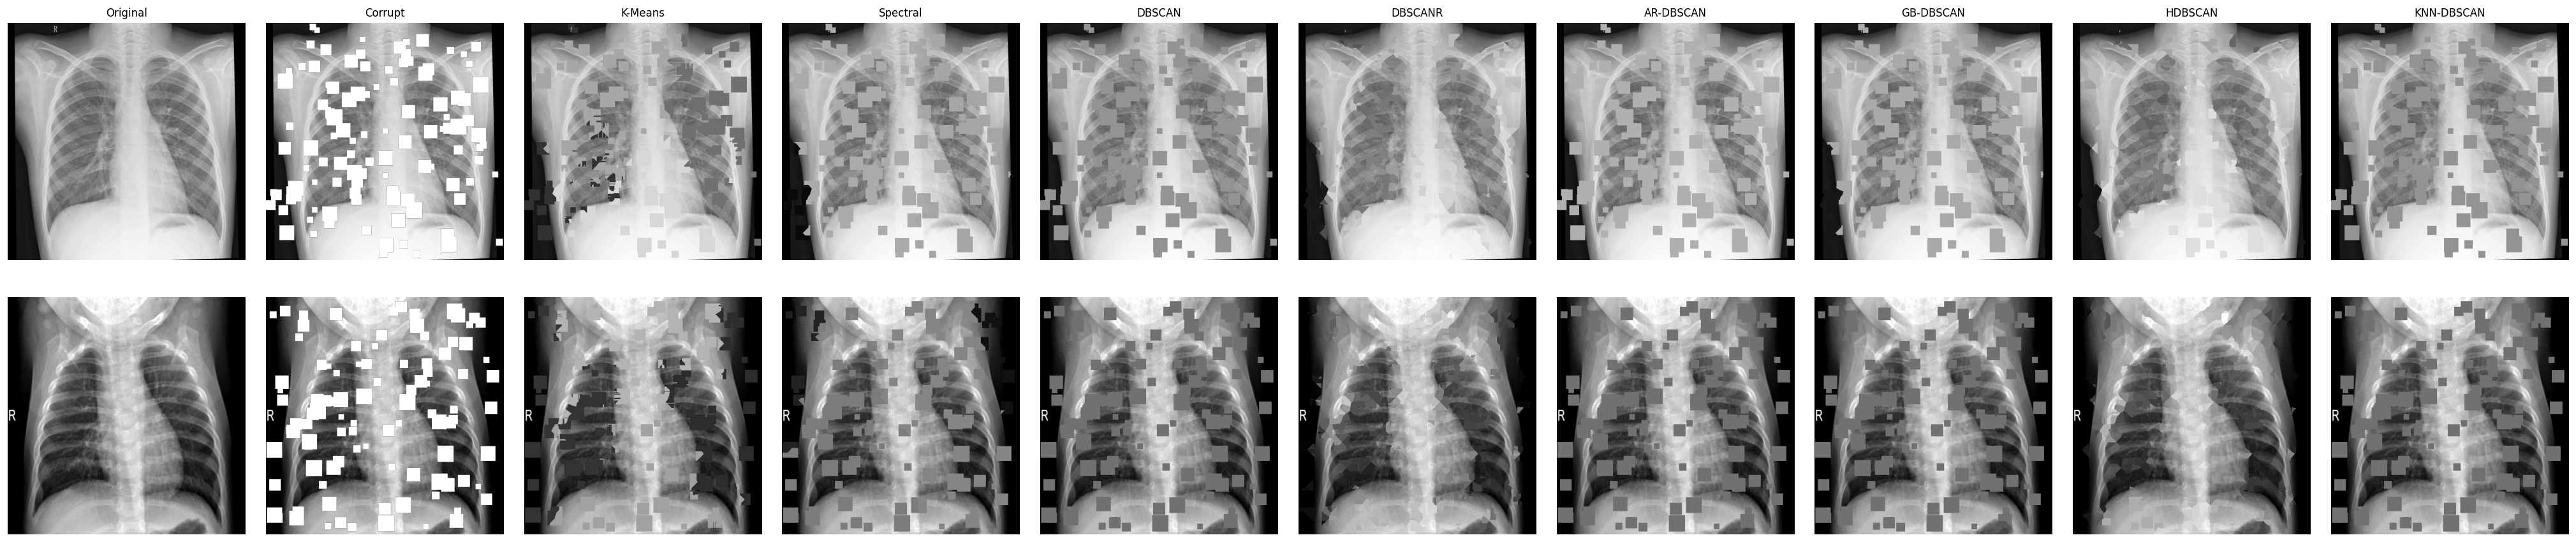

Saved figure: outputs\figures\Chest_X-Ray_qualitative.png
Searching for images in: E:\Uni\Final Project\Datasets\BrainMRI\kaggle_3m
Loaded 30 images.

--- Parameter Justification (Silhouette over subset) ---
k=2 | Avg silhouette=0.3476
k=3 | Avg silhouette=0.3703
k=4 | Avg silhouette=0.3954
k=5 | Avg silhouette=0.3783
k=6 | Avg silhouette=0.3610
Selected k=4

--- Running Brain MRI on 30 images ---
Missing rate: 10%
Missing rate: 20%
Missing rate: 30%

=== FINAL STATISTICS: Brain MRI ===
                       MAE                 RMSE                  PSNR                SSIM                 IoU                 Time          
                      mean       std       mean        std       mean       std      mean       std      mean       std       mean       std
Rate Method                                                                                                                                 
0.1  AR-DBSCAN   22.243318  8.986259  27.566047  10.567169  25.595448  3.444495  0.89

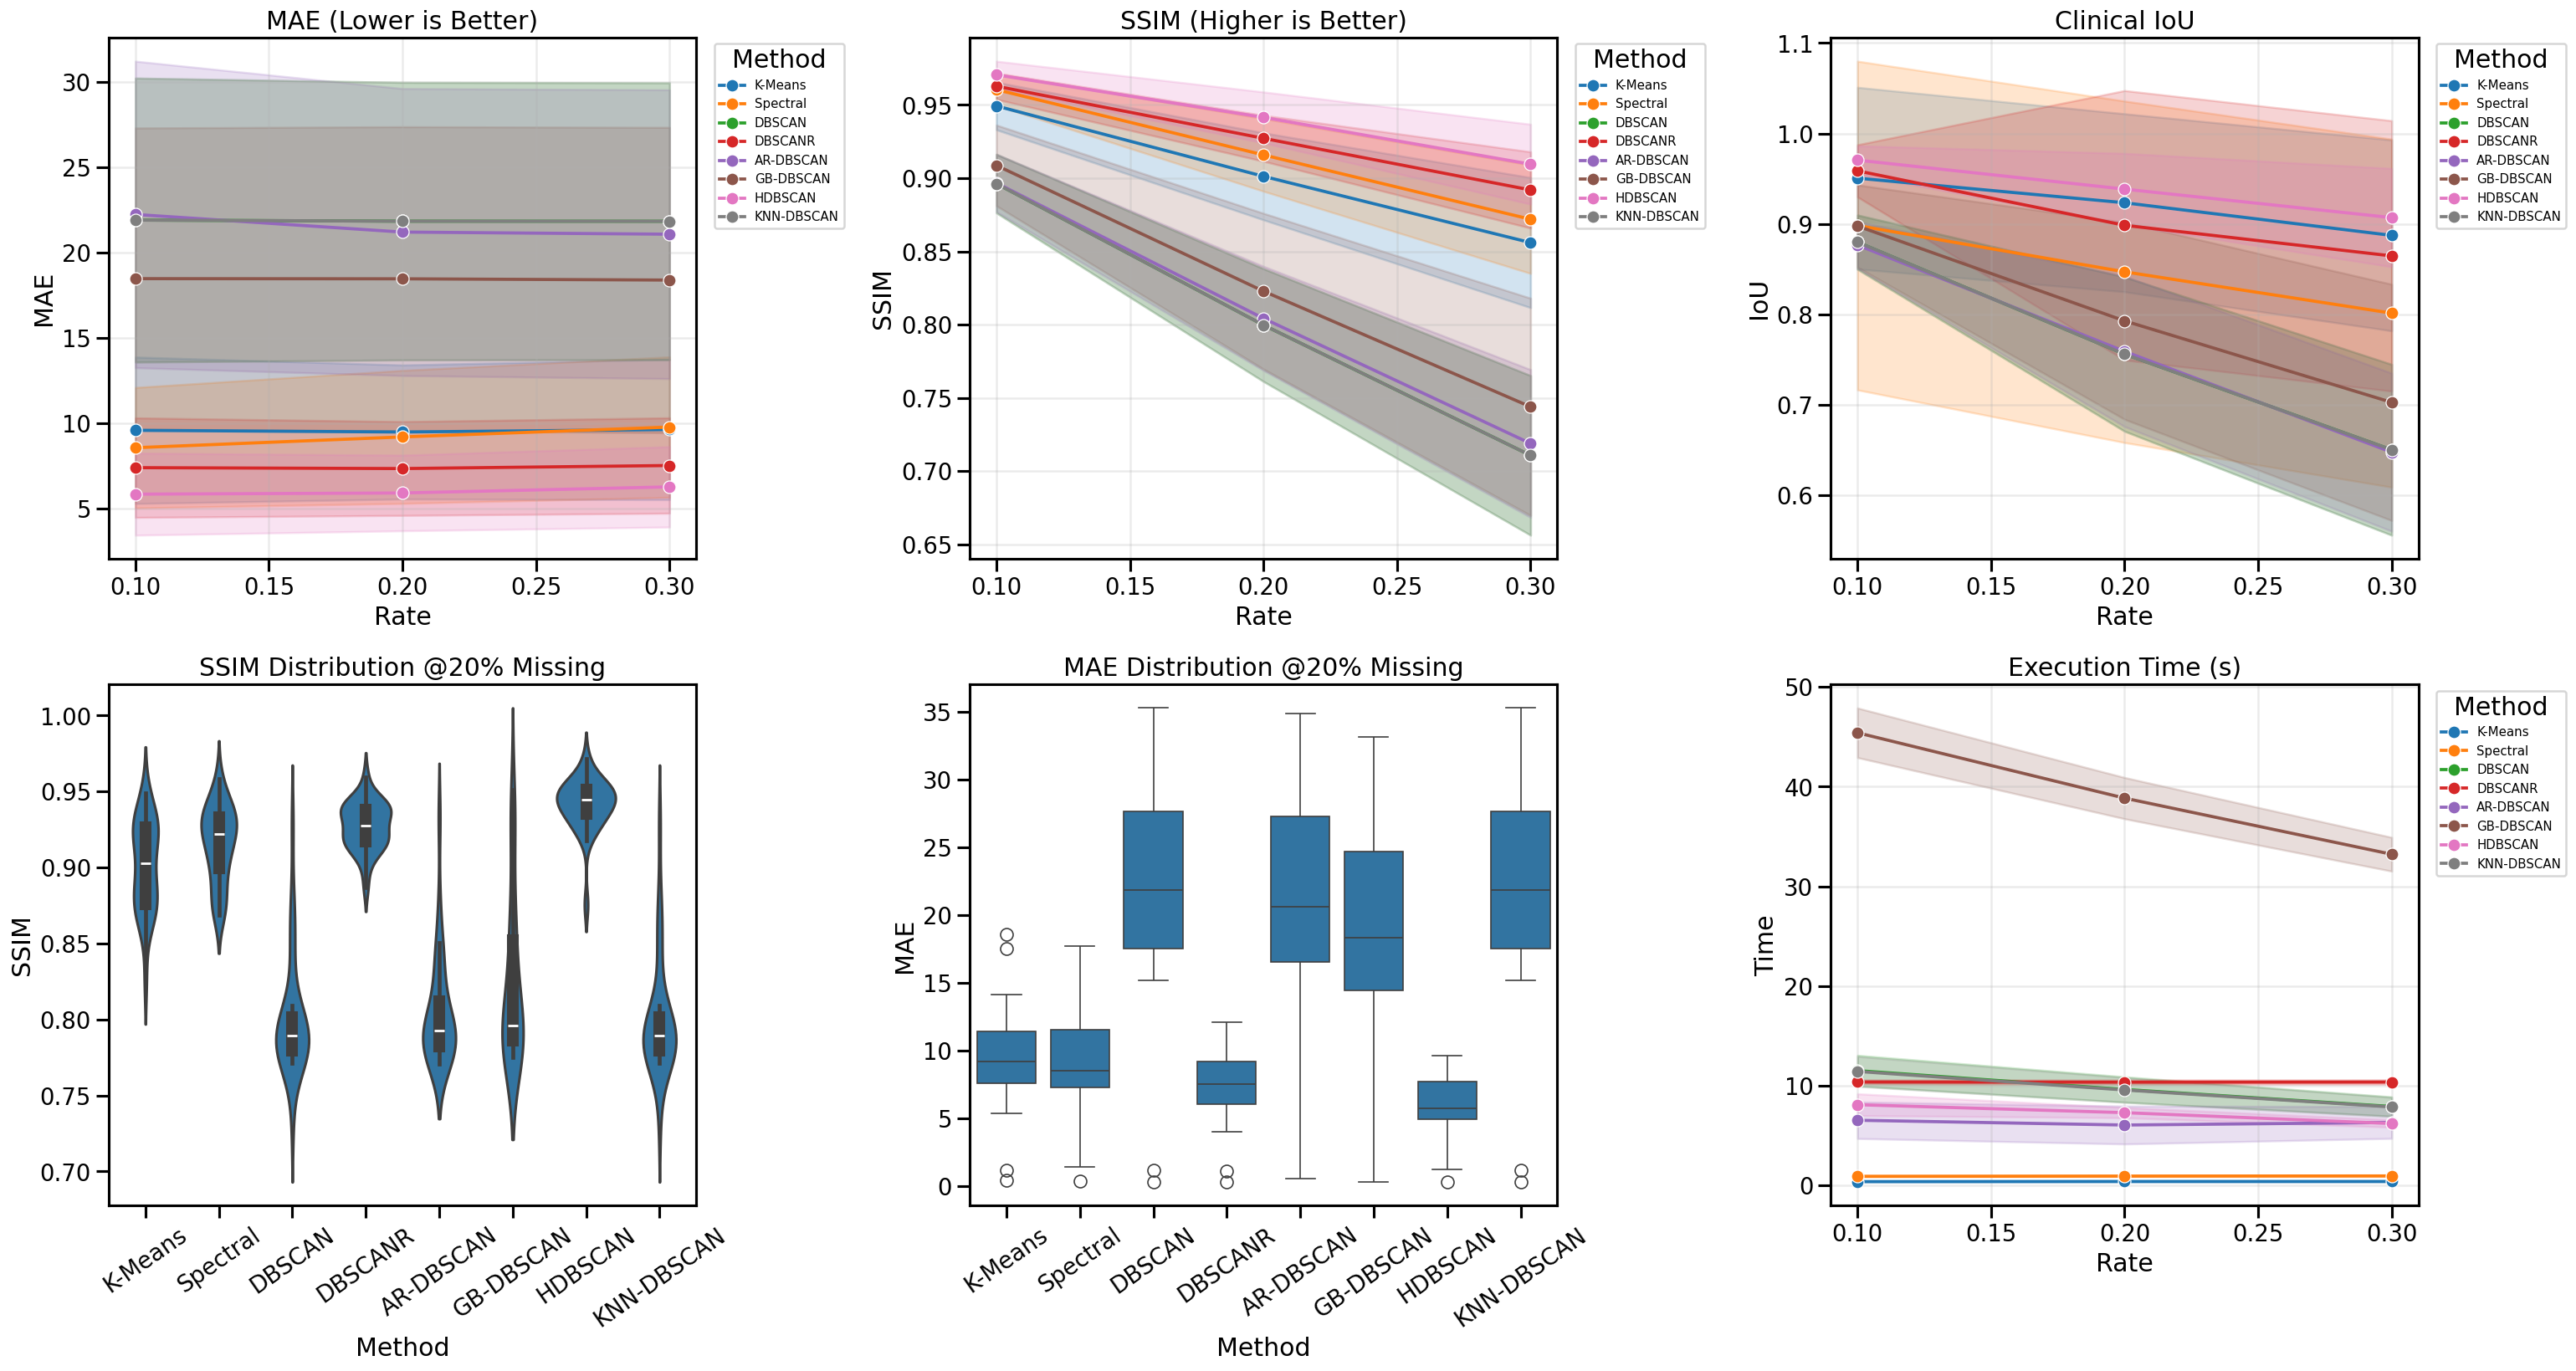

Saved figure: outputs\figures\Brain_MRI_metrics.png


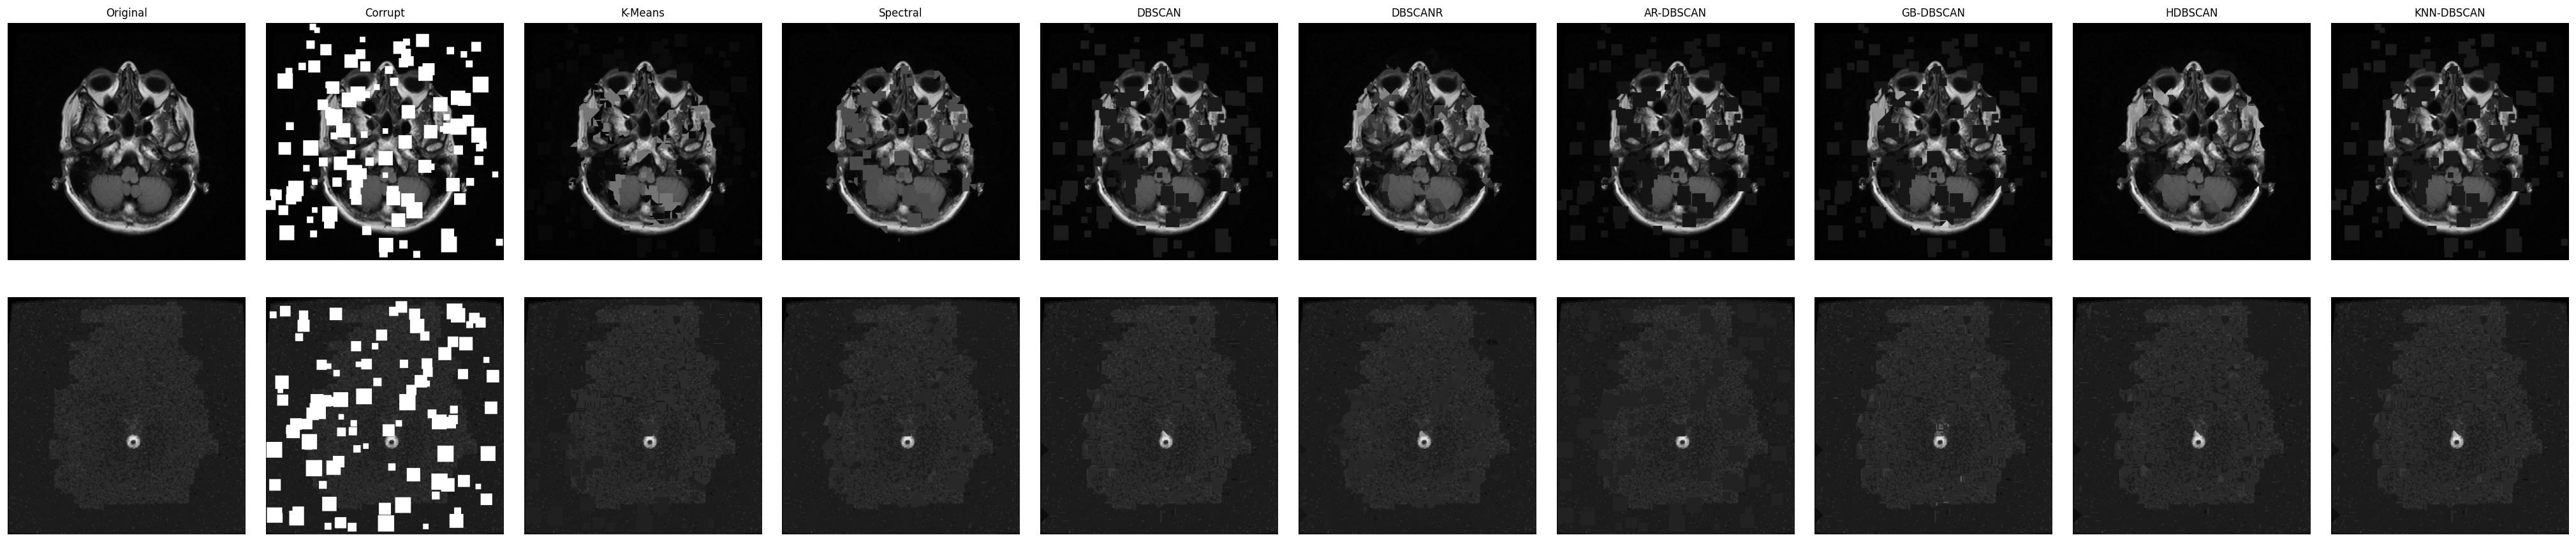

Saved figure: outputs\figures\Brain_MRI_qualitative.png


In [ ]:
"""
FINAL YEAR PROJECT: Medical Image Imputation using Density-Based Clustering
-------------------------------------------------------------------------
Research Question:
    Can density-based clustering reliably reconstruct images under structured data loss?
"""

import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error, mean_absolute_error, jaccard_score, silhouette_score
from sklearn.cluster import KMeans

# Method imports
from methods.kmeans_method import impute_kmeans
from methods.spectral_method import impute_spectral
from methods.dbscan_method import impute_dbscan
from methods.dbscanr_method import impute_dbscanr
from methods.ar_dbscan_method import impute_ar_dbscan
from methods.gb_dbscan_method import impute_gb_dbscan
from methods.hdbscan_method import impute_hdbscan


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1400)

FAST_MODE = False
FAST_N_SAMPLES = 15
FAST_RATES = [0.2]
FAST_SIZE = (192, 192)
# ==========================================
# 1. DATA LOADING
# ==========================================
def load_medical_images(root_path, n_samples=30, target_size=(512, 512)):
    images = []
    print(f"Searching for images in: {root_path}")

    exts = ["*.jpg", "*.jpeg", "*.png", "*.tif", "*.bmp"]
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(root_path, "**", ext), recursive=True))

    files = [f for f in files if "_mask" not in f]

    if len(files) == 0:
        print(f"WARNING: no images found in {root_path}")
        return []

    np.random.seed(42)
    selected = np.random.choice(files, min(n_samples, len(files)), replace=False)

    for fp in selected:
        img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
            images.append(img.astype(float))

    print(f"Loaded {len(images)} images.")
    return images


DATASET_PATHS = {
    "Chest X-Ray": r"E:\Uni\Final Project\Datasets\archive\chest_xray\test\NORMAL",
    "Brain MRI": r"E:\Uni\Final Project\Datasets\BrainMRI\kaggle_3m",
}

# ==========================================
# 2. MISSINGNESS SIMULATION
# ==========================================
def create_structured_loss(image, missing_rate=0.2, seed=None):
    if seed is not None:
        np.random.seed(seed)

    mask = np.zeros_like(image, dtype=bool)
    h, w = image.shape
    target = int(h * w * missing_rate)
    tries = 0

    while np.sum(mask) < target and tries < 3000:
        bs = np.random.randint(12, 36)
        y = np.random.randint(0, h - bs)
        x = np.random.randint(0, w - bs)
        mask[y:y + bs, x:x + bs] = True
        tries += 1

    miss = image.copy()
    miss[mask] = np.nan
    return miss, mask

# ==========================================
# 3. EVALUATION
# ==========================================
def evaluate_clinical_utility(orig, rec):
    orig_u8 = cv2.normalize(orig, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
    rec_u8 = cv2.normalize(rec, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
    _, orig_mask = cv2.threshold(orig_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, rec_mask = cv2.threshold(rec_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return jaccard_score(orig_mask.flatten() > 0, rec_mask.flatten() > 0)

def evaluate(orig, rec, mask):
    o = orig[mask]
    r = rec[mask]
    dr = max(1e-12, orig.max() - orig.min())
    return {
        "MAE": mean_absolute_error(o, r),
        "RMSE": np.sqrt(mean_squared_error(o, r)),
        "PSNR": psnr(orig, rec, data_range=dr),
        "SSIM": ssim(orig, rec, data_range=dr),
        "IoU": evaluate_clinical_utility(orig, rec),
    }

def run_statistical_test(df, benchmark="DBSCAN", metric="SSIM"):
    print(f"\n=== STATISTICAL SIGNIFICANCE (Benchmark: {benchmark}) ===")
    methods = df["Method"].unique()
    bench = df[df["Method"] == benchmark][metric].values

    for m in methods:
        if m == benchmark:
            continue
        comp = df[df["Method"] == m][metric].values
        n = min(len(bench), len(comp))
        if n < 2:
            continue
        if np.allclose(bench[:n], comp[:n]):
            p = 1.0
            sig = "Identical"
        else:
            _, p = wilcoxon(bench[:n], comp[:n])
            sig = "**SIGNIFICANT**" if p < 0.05 else "Not Sig"
        print(f"vs {m:15s} | p={p:.6f} | {sig}")

def justify_parameters(images):
    print("\n--- Parameter Justification (Silhouette over subset) ---")
    subset = images[:min(6, len(images))]
    k_scores = {}

    for img in subset:
        h, w = img.shape
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        data = np.column_stack((y.flatten(), x.flatten(), img.flatten()))
        if len(data) > 5000:
            idx = np.random.choice(len(data), 5000, replace=False)
            data = data[idx]

        for k in range(2, 7):
            km = KMeans(n_clusters=k, random_state=42, n_init=3).fit(data)
            s = silhouette_score(data, km.labels_)
            k_scores.setdefault(k, []).append(s)

    best_k = 2
    best_score = -1
    for k in sorted(k_scores.keys()):
        avg = np.mean(k_scores[k])
        print(f"k={k} | Avg silhouette={avg:.4f}")
        if avg > best_score:
            best_k = k
            best_score = avg

    print(f"Selected k={best_k}")
    return best_k

# ==========================================
# 4. MAIN RUN
# ==========================================
def main():
    os.makedirs("outputs/figures", exist_ok=True)
    os.makedirs("outputs/tables", exist_ok=True)

  
    rates = FAST_RATES if FAST_MODE else [0.1, 0.2, 0.3]

    for dataset_name, dataset_path in DATASET_PATHS.items():
        if not os.path.exists(dataset_path):
            print(f"Path not found, skipping: {dataset_path}")
            continue

        # still 30 by default for stability/runtime
       # images = load_medical_images(dataset_path, n_samples=30, target_size=(512, 512))
        images = load_medical_images(
    dataset_path,
    n_samples=FAST_N_SAMPLES if FAST_MODE else 30,
    target_size=FAST_SIZE if FAST_MODE else (512, 512)
)
        if len(images) == 0:
            continue

        best_k = justify_parameters(images)

        results = []
        print(f"\n--- Running {dataset_name} on {len(images)} images ---")

        for rate in rates:
            print(f"Missing rate: {int(rate * 100)}%")
            for i, img in enumerate(images):
                miss, mask = create_structured_loss(img, missing_rate=rate, seed=i)

                methods = {
                    "K-Means": lambda m: impute_kmeans(m, k=best_k),
                    "Spectral": lambda m: impute_spectral(m, k=best_k),
                    "DBSCAN": lambda m: impute_dbscan(m, eps=0.25, min_samples=5),
                    "DBSCANR": lambda m: impute_dbscanr(
                    m, k=5, K=np.inf, p=2, expand=True, enforceK=False, max_points=6000
                    ),
                    "AR-DBSCAN": lambda m: impute_ar_dbscan(m),
                    "GB-DBSCAN": lambda m: impute_gb_dbscan(m, ratio=0.92),
                    "HDBSCAN": lambda m: impute_hdbscan(m, min_cluster_size=10, min_samples=5),
                }

                for method_name, method_fn in methods.items():
                    t0 = time.time()
                    rec = method_fn(miss)
                    elapsed = time.time() - t0

                    metrics = evaluate(img, rec, mask)
                    results.append([
                        rate, method_name,
                        metrics["MAE"], metrics["RMSE"], metrics["PSNR"], metrics["SSIM"], metrics["IoU"],
                        elapsed
                    ])

        df = pd.DataFrame(results, columns=["Rate", "Method", "MAE", "RMSE", "PSNR", "SSIM", "IoU", "Time"])
        summary = df.groupby(["Rate", "Method"]).agg(["mean", "std"])

        print(f"\n=== FINAL STATISTICS: {dataset_name} ===")
        print(summary[["MAE", "RMSE", "PSNR", "SSIM", "IoU", "Time"]])

        summary_path = os.path.join("outputs", "tables", f"{dataset_name.replace(' ', '_')}_summary.csv")
        df.to_csv(summary_path, index=False)
        print(f"Saved raw results: {summary_path}")

        run_statistical_test(df, benchmark="DBSCAN", metric="SSIM")

        # ==========================================
        # 5. VISUALIZATION
        # ==========================================
        sns.set_context("talk")
        fig, axes = plt.subplots(2, 3, figsize=(26, 14), dpi=120)

        sns.lineplot(data=df, x="Rate", y="MAE", hue="Method", marker="o", errorbar="sd", ax=axes[0, 0])
        axes[0, 0].set_title("MAE (Lower is Better)")
        axes[0, 0].grid(alpha=0.25)

        sns.lineplot(data=df, x="Rate", y="SSIM", hue="Method", marker="o", errorbar="sd", ax=axes[0, 1])
        axes[0, 1].set_title("SSIM (Higher is Better)")
        axes[0, 1].grid(alpha=0.25)

        sns.lineplot(data=df, x="Rate", y="IoU", hue="Method", marker="o", errorbar="sd", ax=axes[0, 2])
        axes[0, 2].set_title("Clinical IoU")
        axes[0, 2].grid(alpha=0.25)

        sns.violinplot(data=df[df["Rate"] == 0.2], x="Method", y="SSIM", ax=axes[1, 0])
        axes[1, 0].set_title("SSIM Distribution @20% Missing")
        axes[1, 0].tick_params(axis="x", rotation=35)

        sns.boxplot(data=df[df["Rate"] == 0.2], x="Method", y="MAE", ax=axes[1, 1])
        axes[1, 1].set_title("MAE Distribution @20% Missing")
        axes[1, 1].tick_params(axis="x", rotation=35)

        sns.lineplot(data=df, x="Rate", y="Time", hue="Method", marker="o", errorbar="sd", ax=axes[1, 2])
        axes[1, 2].set_title("Execution Time (s)")
        axes[1, 2].grid(alpha=0.25)

        for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 2]]:
            handles, labels = ax.get_legend_handles_labels()
            if len(handles) > 0:
                ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title="Method")

        plt.tight_layout()
        fig_path = os.path.join("outputs", "figures", f"{dataset_name.replace(' ', '_')}_metrics.png")
        plt.savefig(fig_path, dpi=160)
        plt.show()
        print(f"Saved figure: {fig_path}")

        cols = ["Original", "Corrupt", "K-Means", "Spectral", "DBSCAN", "DBSCANR", "AR-DBSCAN", "GB-DBSCAN", "HDBSCAN"]
        fig, axs = plt.subplots(2, len(cols), figsize=(34, 8), dpi=120)

        for row in range(2):
            img = images[row]
            miss, _ = create_structured_loss(img, missing_rate=0.2, seed=row)

            recons = [
                img,
                miss,
                impute_kmeans(miss, k=best_k),
                impute_spectral(miss, k=best_k),
                impute_dbscan(miss, eps=0.25, min_samples=5),
                impute_dbscanr(miss, k=5, max_points=6000),
                impute_ar_dbscan(miss),
                impute_gb_dbscan(miss, ratio=0.92),
                impute_hdbscan(miss, min_cluster_size=10, min_samples=5),
            ]

            for c in range(len(cols)):
                axs[row, c].imshow(recons[c], cmap="gray")
                axs[row, c].axis("off")
                if row == 0:
                    axs[row, c].set_title(cols[c], fontsize=10)

        plt.tight_layout()
        fig_path2 = os.path.join("outputs", "figures", f"{dataset_name.replace(' ', '_')}_qualitative.png")
        plt.savefig(fig_path2, dpi=160)
        plt.show()
        print(f"Saved figure: {fig_path2}")

if __name__ == "__main__":
    main()